**Mandatory Assignment 2 Submission - Group 47**

**Imports**

In [1]:
# Imports gathered from lab
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import modules for machine learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.pipeline import make_pipeline

Loads bysykkel table

In [ ]:
import os

# Creates the data folder if it does not exist
os.makedirs('data', exist_ok=True)

# URL to the raw data on GitHub
url = 'https://raw.githubusercontent.com/DAVE3625/Dave3625-2026/main/Mandatory_Assignments/MA2/data/Bysykkel_09.csv'

# Downloads and saves the file locally if it doesn't already exist
filepath = 'data/Bysykkel_09.csv'
if not os.path.exists(filepath):
    print("Downloading Bysykkel_09.csv from GitHub...")
    bysykkel = pd.read_csv(url, sep=',')
    bysykkel.to_csv(filepath, index=False)
else:
    bysykkel = pd.read_csv(filepath, sep=',')

display(bysykkel.head())

,started_at,ended_at,duration,start_station_id,start_station_name,start_station_description,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_description,end_station_latitude,end_station_longitude
0,2025-09-01 03:00:58.648000+00:00,2025-09-01 03:10:55.808000+00:00,597,597,Fredensborg,ved rundkjøringen,59.920995,10.750358,435,Fram-gården,langs Bygdøy Allé,59.915424,10.714577
1,2025-09-01 03:05:24.230000+00:00,2025-09-01 03:08:38.433000+00:00,194,2339,Elgsletta,langs Nylandsveien,59.915649,10.761725,2328,The Hub,mellom Oslo City og The Hub hotel,59.912472,10.750847
2,2025-09-01 03:10:37.948000+00:00,2025-09-01 03:28:34.696000+00:00,1076,620,Bislettgata,ved Sofies Gate,59.923774,10.734713,512,Ensjø T-bane,langs Ensjøveien,59.913189,10.789760
3,2025-09-01 03:14:15.891000+00:00,2025-09-01 03:19:03.853000+00:00,287,746,Bygdøy allé,ved parkeringsplassen,59.919001,10.692321,572,Skøyen,under broen,59.922269,10.679580
4,2025-09-01 03:21:02.841000+00:00,2025-09-01 03:40:02.621000+00:00,1139,422,St. Hanshaugen,langs Waldemar Thranes gate,59.923703,10.740542,484,Karenslyst allé,ved Skabos vei,59.920330,10.683814


Groups the data by Station ID. The table shows ID, station name, location coordinates, number of trips started at the station, average trip length and number of trips ended at the station.

In [3]:
# One row per station, based on trips that STARTED there
started = bysykkel.groupby('start_station_id').agg(
    station_name=('start_station_name', 'first'),
    latitude=('start_station_latitude', 'first'),
    longitude=('start_station_longitude', 'first'),
    trips_started=('start_station_id', 'count'),
    avg_duration=('duration', 'mean')
)

# Number of trips that ENDED at each station
ended = bysykkel.groupby('end_station_id').size().rename('trips_ended')

# Combine the two into one table (one row per station)
stations = started.join(ended, how='left').fillna({'trips_ended': 0})

# Calculate total number of trips as sum of trips started and trips ended
stations['total_number_of_trips'] = stations['trips_started'] + stations['trips_ended']

display(stations.head())
print(stations.shape)

,station_name,latitude,longitude,trips_started,avg_duration,trips_ended,total_number_of_trips
start_station_id,,,,,,,
377,Tøyenparken,59.915667,10.777567,337,710.513353,297,634
380,Bentsebrugata,59.939230,10.759170,1103,748.097915,463,1566
381,Grønlands torg,59.912520,10.762240,607,734.202636,691,1298
382,Stensgata,59.929586,10.732839,313,679.910543,294,607
383,Arkitekt Rivertz Plass,59.934936,10.749466,880,651.603409,391,1271


(267, 7)


Creates the target variable by splitting the stations into Low, Medium and High popularity based on total number of trips.

In [4]:
# Categorizes stations into three equal-sized parts (Low, Medium, High) based on number of trips
tiers = pd.qcut(stations['total_number_of_trips'], 3, labels=['Low', 'Medium', 'High'])
stations['popularity'] = tiers

# Displays the top rows of popularity
display(stations.popularity.head())
# Displays the balance of the three types of stations
display(stations.popularity.value_counts())

start_station_id
377     Low
380    High
381    High
382     Low
383    High
Name: popularity, dtype: category
Categories (3, str): ['Low' < 'Medium' < 'High']

popularity
Low       89
Medium    89
High      89
Name: count, dtype: int64

We chose to use a classification algorithm. The reason for this is that this is a classification problem. The output we are looking for is a class (low, medium, high). We are not looking for the model to output a number, which regression is for. We chose K-Nearest Neighbors because the dataset is small with only five numeric features. Stations with similar usage are likely to have the same popularity, which KNN also assumes. It is therefore a good fit. Because KNN uses distances, we scale the features with StandardScaler.

In [5]:
# Define the features (X) used to predict popularity, and the target variable (y)
X = stations[['latitude', 'longitude', 'trips_started', 'trips_ended', 'avg_duration']]
y = stations['popularity']

# Splits the dataset into 80% training data and 20% test data
# 'random_state=42' is a seed and eensures reproducible results across runs
# 'stratify=y' ensures that the target classes are equally distributed in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [6]:
# Creates a pipeline that first scales the features (StandardScaler)
# and then applies the K-Neighbors Classifier with 5 neighbors
model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))

# Trains the model using the training features and targets
model.fit(X_train, y_train)

# Uses the trained model to make predictions on the unseen test features
y_pred = model.predict(X_test)

Accuracy: 0.85


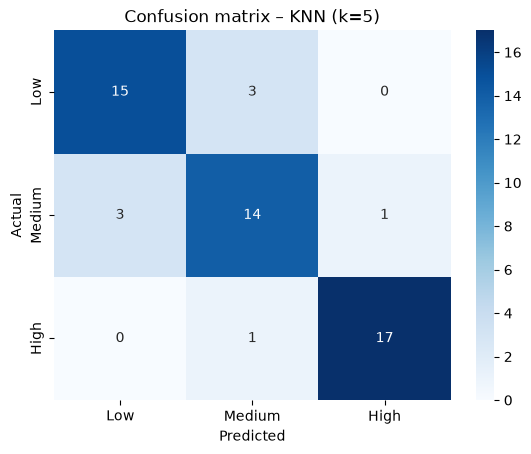

              precision    recall  f1-score   support

        High       0.94      0.94      0.94        18
         Low       0.83      0.83      0.83        18
      Medium       0.78      0.78      0.78        18

    accuracy                           0.85        54
   macro avg       0.85      0.85      0.85        54
weighted avg       0.85      0.85      0.85        54

Cross-validation accuracy: 0.82 ± 0.07


In [7]:
# Calculates and prints the overall model accuracy (the fraction of correct predictions)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Sets up the confusion matrix to compare actual classes (rows) against predicted classes (columns)
labels = ['Low', 'Medium', 'High']
cm = confusion_matrix(y_test, y_pred, labels=labels)

# Visualizes the confusion matrix as a heatmap for intuitive evaluation
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion matrix – KNN (k=5)')
plt.show()

# Generates a detailed classification report showing precision, recall, and f1-score for each class
# - Precision: Out of all predicted as X, how many were actually X?
# - Recall: Out of all actually X, how many did we correctly find?
# - F1-Score: The harmonic mean of precision and recall
print(classification_report(y_test, y_pred))

# Cross validation
scores = cross_val_score(model, X, y, cv=5)
print(f"Cross-validation accuracy: {scores.mean():.2f} ± {scores.std():.2f}")

In the matrix above the rows represent actual results and the columns represent the predicted result.

The model gets an accuracy of 0.85 on the test set. It is best at predicting high popularity stations.

To check that the result was not due to a lucky split, we used 5-fold cross-validation at the end. It gave a mean accuracy of 0.82 +- 0.07, which is close to the 0.85 on the test set. The model's performance is therefore stable, although the accuracy varies somewhat between folds because the dataset is small.

The popularity label is calculated from trips_started and trips_ended, which are also used as features, so the model mainly learns to recognise station usage.
